# Rapport Data Processing and Vizualisation : BSc ISC vs BSc Inf. D gestion (IDG)
James Zeiger\
ID: 11\
Nbr: 25\
Subject: BSc Inf. D gestion

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import nltk
# nltk.download('punkt')
# nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

In [69]:
# Read a file
text1_1 = Path("res/website-full.txt").read_text()
text2_1 = Path("res/my_website_full.txt").read_text()

## Generic info

#### From word count website:
ISC:\
Words = 1'591\
Sent = 62\
Chars = 10'586

IDG :\
Words = 1'655\
Sent = 63\
Chars = 11'774

ISC (unfiltered)
Number of words:         1775
Number of sentences:     51
Number of unique words:  704
///////////////////////////////////
Inf. D gestion (unfiltered)
Number of words:         1857
Number of sentences:     53
Number of unique words:  800


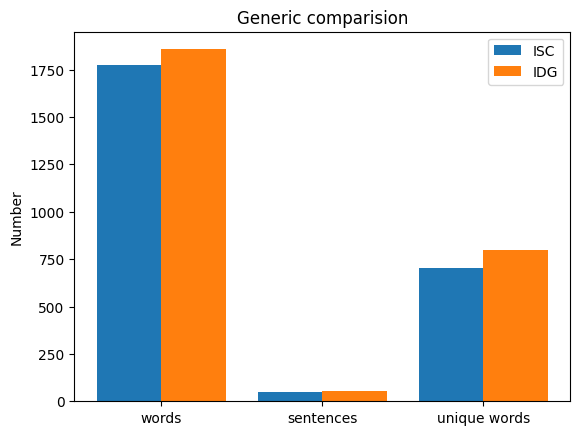

In [70]:
w1        = word_tokenize(text1_1)
w2        = word_tokenize(text2_1)
nbr_w1    = len(w1)
nbr_w2    = len(w2)
nbr_sen1  = len(sent_tokenize(text1_1))
nbr_sen2  = len(sent_tokenize(text2_1))
nbr_uw1   = len(set(w1))
nbr_uw2   = len(set(w2))

print("ISC (unfiltered)")
print("Number of words:        ", nbr_w1)
print("Number of sentences:    ", nbr_sen1)
print("Number of unique words: ", nbr_uw1)

print("///////////////////////////////////")
print("Inf. D gestion (unfiltered)")
print("Number of words:        ", nbr_w2)
print("Number of sentences:    ", nbr_sen2)
print("Number of unique words: ", nbr_uw2)

x_names = np.array(["words", "sentences", "unique words"])
d1 = [nbr_w1, nbr_sen1, nbr_uw1]
d2 = [nbr_w2, nbr_sen2, nbr_uw2]

w, x = 0.4, np.arange(len(x_names))
fig, ax = plt.subplots()
ax.bar(x - w/2, d1, width=w, label='ISC')
ax.bar(x + w/2, d2, width=w, label='IDG')

ax.set_xticks(x)
ax.set_xticklabels(x_names)
ax.set_ylabel('Number')
ax.set_title('Generic comparision')
ax.legend()
plt.show()


We can observe the raw text distribution of both websites and we could almost say that they are similar.

However, for such a small website, there are way more words in ISC than in Inf. d gestion, but fewer unique words.
This could mean that the ISC website has more words per sentence, that most likely contain a larger number of filler words.

We could then conclude that the ISC website conatains a few too many long sentences, with potentially too many filler words.

# Pre-Processing

Here we are going through the first process of word filtering, which is the removal of filler words (or stop words).\
This will help us extract the key words that aren't simply the most frequent such as `I, was, the, it`.

The removal of punctiation is also necessary for the same reasons.

In [72]:
def filter_words(text):
  stop_words = set(stopwords.words('english'))
  word_tokens = word_tokenize(text)

  # no stop words
  filtered_text = [w for w in word_tokens if not w.lower() in stop_words]

  return filtered_text

# create new filtered text without punctuation or filler words
with open("res/website_filtered.txt", "w") as f:
  for word in filter_words(text1_1):
    f.write(word + " ")
with open("res/my_website_filtered.txt", "w") as f:
  for word in filter_words(text2_1):
    f.write(word + " ")


nbr_w1  = len(filter_words(text1_1))
nbr_w2  = len(filter_words(text2_1))
nbr_uw1 = len(set(filter_words(text1_1)))
nbr_uw2 = len(set(filter_words(text2_1)))


# write to .txt file
text1_2 = Path("res/website_filtered.txt").read_text()
text2_2 = Path("res/my_website_filtered.txt").read_text()

Percentage of words filtered:
ISC: 32.9 | IDG: 24.5

How many duplicate non-stop-words:
ISC: 584 | IDG: 455


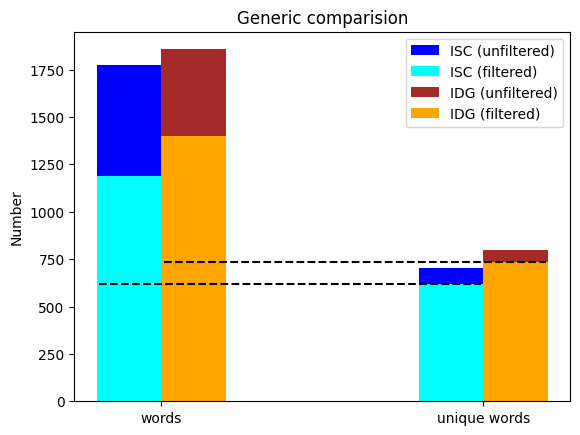

In [ ]:
d1_1 = [d1[0], d1[2]]
d2_1 = [d2[0], d2[2]]
d1_2 = [nbr_w1, nbr_uw1]
d2_2 = [nbr_w2, nbr_uw2]

print(f"Percentage of words filtered:\nISC: {round(100-d1_2[0]/d1_1[0]*100, 2)} | IDG: {round(100-d2_2[0]/d2_1[0]*100, 2)}\n")
print(f"How many duplicate non-stop-words:\nISC: {d1_1[0]-d1_2[0]} | IDG: {d2_1[0]-d2_2[0]}")

x_names = np.array(["words", "unique words"])
w, x = 0.2, np.arange(len(x_names))
fig, ax = plt.subplots()
ax.bar(x - w/2, d1_1, width=w, label='ISC (unfiltered)', color='blue')
ax.bar(x - w/2, d1_2, width=w, label='ISC (filtered)', color='cyan')
ax.bar(x + w/2, d2_1, width=w, label='IDG (unfiltered)', color='brown')
ax.bar(x + w/2, d2_2, width=w, label='IDG (filtered)', color='orange')

ax.axhline(y=d1_2[1], color='black', linestyle='--', xmin=0.05, xmax=0.82)
ax.axhline(y=d2_2[1], color='black', linestyle='--', xmin=0.18, xmax=0.95)

ax.set_xticks(x)
ax.set_xticklabels(x_names)
ax.set_ylabel('Number')
ax.set_title('Generic comparision')
ax.legend()
plt.show()

By simply cleaning up the filler words, we can see that ISC's number of words has greatly reduced. This clearly means that there is a lot of uninteresting text due to the amount of filler words.

IDG's word count may be higher, but there are already signs of it containing more interesting and maybe even subject orientated words.

<!-- Having said that, we can see that about 40% of ISC's filtered words are unique versus  -->

## Wordcloud
`Why it's usefull:`\
This form of vizualisation determines whether or not the website contains the key words people are looking for.
A university course website should primarily contain words associated with the subject.

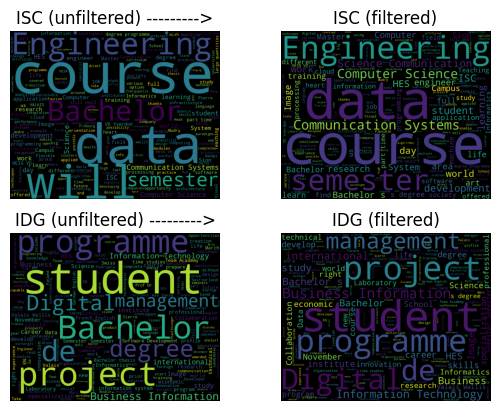

In [ ]:
from wordcloud import WordCloud

wordcloud1_1 = WordCloud(width=1000, height=800).generate(text1_1)
wordcloud1_2 = WordCloud(width=1000, height=800).generate(text1_2)
wordcloud2_1 = WordCloud(width=1000, height=800).generate(text2_1)
wordcloud2_2 = WordCloud(width=1000, height=800).generate(text2_2)

fig, axarr = plt.subplots(2,2)
axarr[0,0].imshow(wordcloud1_1)
axarr[0,0].axis("off")
axarr[0,0].set_title("ISC (unfiltered) --------->")

axarr[0,1].imshow(wordcloud1_2)
axarr[0,1].axis("off")
axarr[0,1].set_title("ISC (filtered)")


axarr[1,0].imshow(wordcloud2_1)
axarr[1,0].axis("off")
axarr[1,0].set_title("IDG (unfiltered) --------->")

axarr[1,1].imshow(wordcloud2_2)
axarr[1,1].axis("off")
axarr[1,1].set_title('IDG (filtered)')
plt.show()

Description....

And we can observe that there is the word "de" in IDG's website. This is because when there are addresses mentionned and other similar in the website, they are in french even if the page language is english. We could, but won't go further by filtering french stop-words as well but "de" is the only obvious one.